# **Gapminder introduction to data science using Julia**
By [Carlos Mendez](https://carlos-mendez.org)

## The Gapminder story

Hans Rosling's famous visualization reveals:

* **Global poverty:** In 1810, nearly all countries were poor and sick.
* **Big divergence:** The Industrial Revolution propelled Western nations forward, creating a vast gap with colonized regions.
* **Some convergence:** Post-colonialism, some developing countries significantly improved their health and wealth, narrowing the historical divide.

> Explore and discover our world in data: https://ourworldindata.org

## Data science workflow

![](https://r4ds.hadley.nz/diagrams/data-science/base.png)

Source: [R for Data Science](https://r4ds.hadley.nz/)

## Setup

In [1]:
using Pkg
Pkg.add(["CSV", "DataFrames", "Downloads", "Plots", "GLM", "StatsBase"])

   Resolving 

package versions...


    Updating `~/.julia/environments/v1.12/Project.toml`
  [f43a241f] + Downloads v1.7.0
    Manifest No packages added to or removed from `~/.julia/environments/v1.12/Manifest.toml`


In [2]:
using CSV, DataFrames, Downloads, Statistics, Plots, GLM, StatsBase

## Import data

In [3]:
url = "https://github.com/quarcs-lab/data-open/raw/master/isds/gapminder.csv"
df = CSV.read(Downloads.download(url), DataFrame)

Row,country,continent,year,lifeExp,pop,gdpPercap
,String31,String15,Int64,Float64,Int64,Float64
1,Afghanistan,Asia,1952,28.801,8425333,779.445
2,Afghanistan,Asia,1957,30.332,9240934,820.853
3,Afghanistan,Asia,1962,31.997,10267083,853.101
4,Afghanistan,Asia,1967,34.02,11537966,836.197
5,Afghanistan,Asia,1972,36.088,13079460,739.981
6,Afghanistan,Asia,1977,38.438,14880372,786.113
7,Afghanistan,Asia,1982,39.854,12881816,978.011
8,Afghanistan,Asia,1987,40.822,13867957,852.396
9,Afghanistan,Asia,1992,41.674,16317921,649.341


In [4]:
# Check dimensions
size(df)

(1704, 6)

In [5]:
# First rows
first(df, 5)

Row,country,continent,year,lifeExp,pop,gdpPercap
,String31,String15,Int64,Float64,Int64,Float64
1,Afghanistan,Asia,1952,28.801,8425333,779.445
2,Afghanistan,Asia,1957,30.332,9240934,820.853
3,Afghanistan,Asia,1962,31.997,10267083,853.101
4,Afghanistan,Asia,1967,34.02,11537966,836.197
5,Afghanistan,Asia,1972,36.088,13079460,739.981


In [6]:
# Column names and types
describe(df)

Row,variable,mean,min,median,max,nmissing,eltype
,Symbol,Union…,Any,Union…,Any,Int64,DataType
1,country,,Afghanistan,,Zimbabwe,0,String31
2,continent,,Africa,,Oceania,0,String15
3,year,1979.5,1952,1979.5,2007,0,Int64
4,lifeExp,59.4744,23.599,60.7125,82.603,0,Float64
5,pop,2.96012e7,60011,7.0236e6,1318683096,0,Int64
6,gdpPercap,7215.33,241.166,3531.85,1.13523e5,0,Float64


## Summarize data

In [7]:
# Summary statistics for key variables
describe(df, :mean, :std, :min, :median, :max, cols=[:lifeExp, :gdpPercap, :pop])

Row,variable,mean,std,min,median,max
,Symbol,Float64,Float64,Real,Float64,Real
1,lifeExp,59.4744,12.9171,23.599,60.7125,82.603
2,gdpPercap,7215.33,9857.45,241.166,3531.85,1.13523e5
3,pop,2.96012e7,1.06158e8,60011,7.0236e6,1318683096


In [8]:
# Filter for year 2007
df2007 = filter(row -> row.year == 2007, df)

describe(df2007, :mean, :std, :min, :median, :max, cols=[:lifeExp, :gdpPercap])

Row,variable,mean,std,min,median,max
,Symbol,Float64,Float64,Float64,Float64,Float64
1,lifeExp,67.0074,12.073,39.613,71.9355,82.603
2,gdpPercap,11680.1,12859.9,277.552,6124.37,49357.2


## Visualize data

### Plot V1: Simple scatter plot

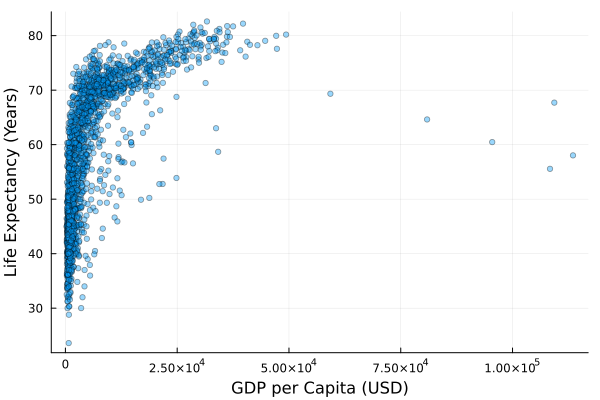

In [9]:
scatter(df.gdpPercap, df.lifeExp,
    xlabel = "GDP per Capita (USD)",
    ylabel = "Life Expectancy (Years)",
    legend = false,
    alpha = 0.4,
    markersize = 3)

> How can we improve this graph?

### Plot V2: Focus on year 2007 and color by continent

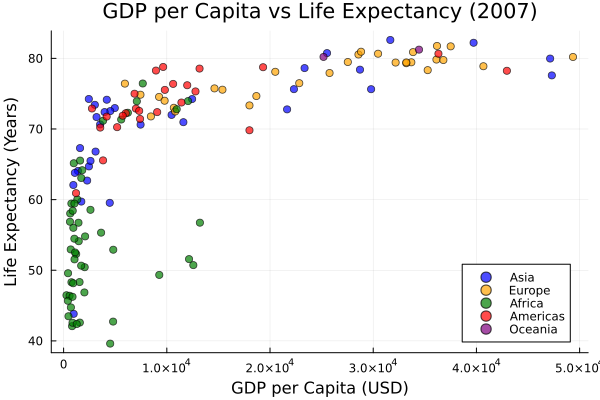

In [10]:
# Get unique continents and assign colors
continents = unique(df2007.continent)
colors = [:blue, :orange, :green, :red, :purple]

p = plot(xlabel = "GDP per Capita (USD)",
         ylabel = "Life Expectancy (Years)",
         title = "GDP per Capita vs Life Expectancy (2007)")

for (i, cont) in enumerate(continents)
    sub = filter(row -> row.continent == cont, df2007)
    scatter!(p, sub.gdpPercap, sub.lifeExp,
        label = cont,
        alpha = 0.7,
        markersize = 4,
        color = colors[i])
end
p

### Plot V3: Log scale is useful when data is skewed

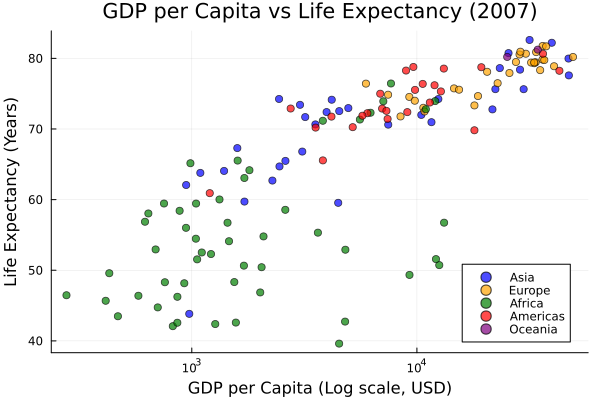

In [11]:
p = plot(xlabel = "GDP per Capita (Log scale, USD)",
         ylabel = "Life Expectancy (Years)",
         title = "GDP per Capita vs Life Expectancy (2007)",
         xscale = :log10)

for (i, cont) in enumerate(continents)
    sub = filter(row -> row.continent == cont, df2007)
    scatter!(p, sub.gdpPercap, sub.lifeExp,
        label = cont,
        alpha = 0.7,
        markersize = 4,
        color = colors[i])
end
p

### Plot V4: Show multiple years

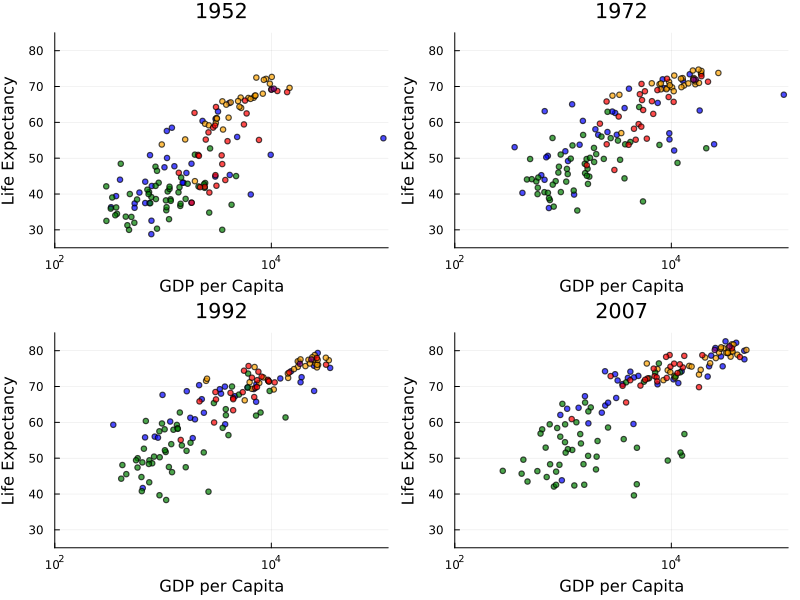

In [12]:
selected_years = [1952, 1972, 1992, 2007]

p = plot(layout = (2, 2), size = (800, 600), legend = false)

for (j, yr) in enumerate(selected_years)
    dfyr = filter(row -> row.year == yr, df)
    for (i, cont) in enumerate(continents)
        sub = filter(row -> row.continent == cont, dfyr)
        scatter!(p, sub.gdpPercap, sub.lifeExp,
            subplot = j,
            title = string(yr),
            xlabel = "GDP per Capita",
            ylabel = "Life Expectancy",
            xscale = :log10,
            xlims = (100, 120000),
            ylims = (25, 85),
            alpha = 0.7,
            markersize = 3,
            color = colors[i],
            label = cont)
    end
end
p

## Transform data

In [13]:
# Create log-transformed variables
df.ln_le = log.(df.lifeExp)
df.ln_gdppc = log.(df.gdpPercap)

first(df, 5)

Row,country,continent,year,lifeExp,pop,gdpPercap,ln_le,ln_gdppc
,String31,String15,Int64,Float64,Int64,Float64,Float64,Float64
1,Afghanistan,Asia,1952,28.801,8425333,779.445,3.36041,6.65858
2,Afghanistan,Asia,1957,30.332,9240934,820.853,3.4122,6.71034
3,Afghanistan,Asia,1962,31.997,10267083,853.101,3.46564,6.74888
4,Afghanistan,Asia,1967,34.02,11537966,836.197,3.52695,6.72886
5,Afghanistan,Asia,1972,36.088,13079460,739.981,3.58596,6.60662


### Plot V5: Scatter plot in log units

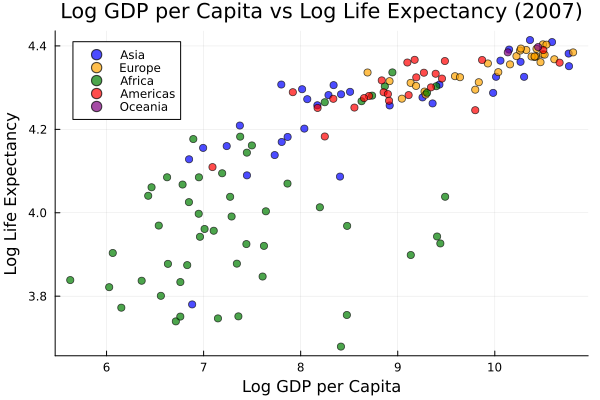

In [14]:
df2007 = filter(row -> row.year == 2007, df)

p = plot(xlabel = "Log GDP per Capita",
         ylabel = "Log Life Expectancy",
         title = "Log GDP per Capita vs Log Life Expectancy (2007)")

for (i, cont) in enumerate(continents)
    sub = filter(row -> row.continent == cont, df2007)
    scatter!(p, sub.ln_gdppc, sub.ln_le,
        label = cont,
        alpha = 0.7,
        markersize = 4,
        color = colors[i])
end
p

## Data modeling

### Plot V6: Add regression line

In [15]:
# Fit a linear regression: ln_le ~ ln_gdppc
model = lm(@formula(ln_le ~ ln_gdppc), df2007)
println(model)

StatsModels.

TableRegressionModel{LinearModel{GLM.LmResp{Vector{Float64}

}, GLM.DensePredChol{Float64, LinearAlgebra.CholeskyPivoted{Float64, Matrix{Float64}, Vector{Int64}}}}, Matrix{Float64}}(LinearModel{GLM.LmResp{Vector{Float64}}, GLM.DensePredChol{Float64, LinearAlgebra.CholeskyPivoted{Float64, Matrix{Float64}, Vector{Int64}}}}:

Coefficients:


───────────────────────────────────────────────────────────────


       Coef.  Std. Error      t  Pr(>|t|)  Lower 95%  Upper 95%
───────────────────────────────────────────────────────────────


...

{Float64}, ln_gdppc::Vector{Float64}}, LinearModel}(ln_le ~ 1 + ln_gdppc, StatsModels.Schema with 2 

entries:
  ln_le => ln_le
  ln_gdppc => ln_gdppc
, (

ln_le = [3.780272882543147, 4.336283697987302, 4.2808379603277125, 3.754924652143619, 4.3217457037889515, 4.397346188781714, 4.379886846960183, 4.325919139014163, 4.15985136442422, 4.375014607774506, 4.038267916001695, 4.182874230468454, 4.315512830615543, 3.9264780263977306, 4.28206816830505, 4.290527931953528, 3.9569007642062317, 3.9035875266070446, 4.08971720583661, 3.920586236088634, 4.390156001647532, 3.800890307175629, 3.9249589738364192, 4.363773556206571, 4.2899250518124985, 4.288937735996952, 4.176723001488003, 3.838634774198773, 4.013170659432992, 4.366684544374611, 3.87801110283644, 4.327412041400659, 4.3602027159438475, 4.337107717548803, 4.36095620405459, 4.003525946889517, 4.279924692981345, 4.31740811033614, 4.267429144774658, 4.274970237376896, 3.94311461290582, 4.061132428015987, 3.969291413218538, 4.3734020496312525, 4.39020559559708, 4.0383913042429525, 4.0851019808551685, 4.374573932148697, 4.094711161682973, 4.37554316231602, 4.2521884138869765, 4.0254766829233, 3.

[1.0 6.882006956185797; 1.0 8.688964207477106; 1.0 8.736066432319678; 1.0 8.475794211096686; 1.0 9.455588185282302; 1.0 10.446839438460565; 1.0 10.494781744976294; 1.0 10.302131057660269; 1.0 7.237960628192509; 1.0 10.425033658433435; 1.0 7.27329026764787; 1.0 8.248564991242306; 1.0 8.915472382958686; 1.0 9.439056509151994; 1.0 9.11226446181318; 1.0 9.27620234384137; 1.0 7.104171203548545; 1.0 6.063949594245329; 1.0 7.446455969467286; 1.0 7.621731638185456; 1.0 10.500102769993411; 1.0 6.559638660731664; 1.0 7.440771103403637; 1.0 9.48582122511248; 1.0 8.508982546938816; 1.0 8.854605046315045; 1.0 6.8938063222615895; 1.0 5.626007793925132; 1.0 8.19769230667367; 1.0 9.17420129338591; 1.0 7.342617436444727; 1.0 9.590092566363756; 1.0 9.099196824890761; 1.0 10.035975648428332; 1.0 10.471026688821484; 1.0 7.641315522621272; 1.0 8.703734955926622; 1.0 8.835394138005636; 1.0 8.627155681368093; 1.0 8.653183423565686; 1.0 9.405420997068234; 1.0 6.463605770695175; 1.0 6.537858417895999; 1.0 10.4

[1, 2]))


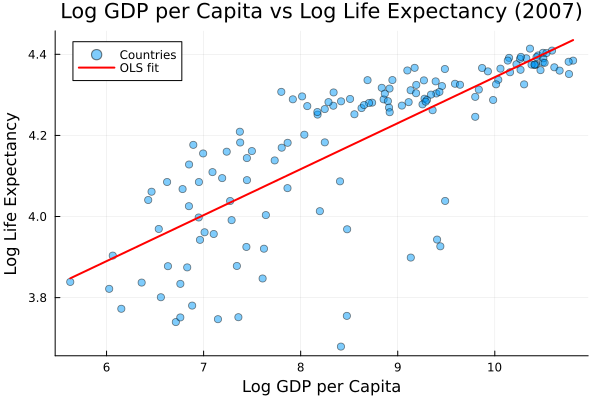

In [16]:
# Scatter plot with regression line
scatter(df2007.ln_gdppc, df2007.ln_le,
    xlabel = "Log GDP per Capita",
    ylabel = "Log Life Expectancy",
    title = "Log GDP per Capita vs Log Life Expectancy (2007)",
    label = "Countries",
    alpha = 0.5,
    markersize = 4)

# Add regression line
x_range = range(extrema(df2007.ln_gdppc)..., length=100)
y_pred = coef(model)[1] .+ coef(model)[2] .* x_range
plot!(x_range, y_pred, linewidth=2, color=:red, label="OLS fit")

### Regression results

In [17]:
# Full regression summary
model

StatsModels.TableRegressionModel{LinearModel{GLM.LmResp{Vector{Float64}}, GLM.DensePredChol{Float64, LinearAlgebra.CholeskyPivoted{Float64, Matrix{Float64}, Vector{Int64}}}}, Matrix{Float64}}

ln_le ~ 1 + ln_gdppc

Coefficients:
────────────────────────────────────────────────────────────────────────
                Coef.  Std. Error      t  Pr(>|t|)  Lower 95%  Upper 95%
────────────────────────────────────────────────────────────────────────
(Intercept)  3.20937   0.0670592   47.86    <1e-87  3.07679     3.34195
ln_gdppc     0.113429  0.00768931  14.75    <1e-29  0.0982271   0.128631
────────────────────────────────────────────────────────────────────────

In [18]:
# Coefficients table
coeftable(model)

|             |    Coef. | Std. Error |     t | Pr(>|t|) | Lower 95% | Upper 95% |
|:------------|---------:|-----------:|------:|:---------|:----------|----------:|
| (Intercept) | 3.20937  | 0.0670592  | 47.86 |   <1e-87 | 3.07679   |  3.34195 |
| ln_gdppc    | 0.113429 | 0.00768931 | 14.75 |   <1e-29 | 0.0982271 |  0.128631 |

In [19]:
# R-squared
println("R² = ", round(r2(model), digits=3))
println("Adjusted R² = ", round(adjr2(model), digits=3))

R² = 0.609


Adjusted R² = 0.606


In [20]:
# Confidence intervals for coefficients
confint(model)

2×2 Matrix{Float64}:
 3.07679    3.34195
 0.0982271  0.128631

### Interpretation

- The coefficient of `ln_gdppc` tells us the **elasticity** of life expectancy with respect to GDP per capita.
- The p-value tests whether this relationship is statistically significant.
- The R² tells us how much of the variation in life expectancy is explained by GDP per capita.
- The confidence interval gives us a range of plausible values for the true coefficient.

### Plot V7: Regression lines by continent

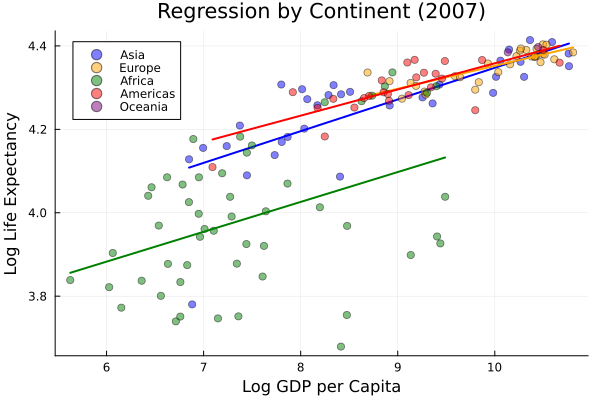

In [21]:
p = plot(xlabel = "Log GDP per Capita",
         ylabel = "Log Life Expectancy",
         title = "Regression by Continent (2007)")

for (i, cont) in enumerate(continents)
    sub = filter(row -> row.continent == cont, df2007)
    scatter!(p, sub.ln_gdppc, sub.ln_le,
        label = cont,
        alpha = 0.5,
        markersize = 4,
        color = colors[i])

    # Fit regression for each continent
    if nrow(sub) > 2
        m = lm(@formula(ln_le ~ ln_gdppc), sub)
        x_r = range(extrema(sub.ln_gdppc)..., length=50)
        y_r = coef(m)[1] .+ coef(m)[2] .* x_r
        plot!(p, x_r, y_r, linewidth=2, color=colors[i], label="")
    end
end
p

## Discussion questions

1. Based on your data exploration, what is the "big picture" story about the relationship between income and health?

2. How is the relationship between GDP per capita and life expectancy changing over time and across continents?

3. What limitations can you find in this exploratory analysis? How could you address those limitations?